<a href="https://colab.research.google.com/github/gph05010/Daily-Study-Log-DeepLearning/blob/main/DeepLearning/ex05_%EC%86%90%EA%B8%80%EC%94%A8_%EB%8D%B0%EC%9D%B4%ED%84%B0_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 이전 코드 참고해서
# 데이터 불러오고
# CNN 모델 설계해서 손글씨 데이터 학습시켜보기
# CNN 모델 설계 후 학습 중에 에러가 발생할 수 있는데, 그 이유 생각해보기
# CNN 모델이 특성을 추출하는 원리, 이미지 데이터 크기와 관련

# 직접 쓴 손글씨 예측시켜 보고 마무리

In [1]:
# keras에서 제공하는 데이터셋 사용
from tensorflow.keras.datasets import mnist

# 훈련용, 테스트용 데이터를 나눠서 제공
(X_train, y_train), (X_test, y_test) = mnist.load_data()

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)
# 학습용 데이터 6만장, 테스트용 데이터 1만장
# 1개의 문제데이터 -> 28*28 픽셀을 가지는 이미지
# 픽셀 : 사진의 정보를 가지는 가장 작은 단위

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, InputLayer, Flatten
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Conv2D, MaxPooling2D

In [11]:
# CNN 모델 설계
cnn_model = Sequential()

# 입력층
cnn_model.add(InputLayer(shape=(28, 28, 1)))

# 특성 추출부
cnn_model.add(
    Conv2D(
        filters=32,        # 필터(돋보기) 개수 : 이 층을 통과하고 나면 32개의 다른 특징들을 담은 데이터로 변환
        kernel_size=(3,3), # 필터의 크기 : 데이터를 스캔할 때 사용되는 행렬의 가로세로 길이
        activation="relu", # 비선형성 변환
        padding="same",    # same : 이미지 자체가 작거나, 가장자리 정보가 중요할 때
                           # valid : 이미지 자체가 크거나, 특징들이 많을 경우
                           # 패딩 : 입출력 크기를 동일하게 하기 위해 가장자리에 숫자를 채워넣는 기능
        strides=(2,2)      # 커널의 보폭 : 양 옆, 위 아래로 2px씩 커널 이동시킴
    )
)

cnn_model.add(
    MaxPooling2D(
        pool_size=(2,2)    # 풀링 윈도우의 크기를 설정(2*2, 3*3 많이 사용)
    )
)

cnn_model.add(Conv2D(filters=64, kernel_size=(3,3), activation="relu", padding="same"))
cnn_model.add(MaxPooling2D(pool_size=(2,2)))

cnn_model.add(Conv2D(filters=64, kernel_size=(3,3), activation="relu", padding="same"))
cnn_model.add(MaxPooling2D(pool_size=(2,2)))

# 1차원 변환 / 앞에서 특성 추출을 한 이후에 1차원 변환
cnn_model.add(Flatten())

cnn_model.add(Dense(256, activation="relu"))
cnn_model.add(Dense(128, activation="relu"))
cnn_model.add(Dense(64, activation="relu"))

cnn_model.add(Dense(10, activation="softmax"))

In [12]:
cnn_model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer = "adam",
    metrics=["accuracy"]
)

In [13]:
cnn_his = cnn_model.fit(
    X_train, y_train,
    validation_split=0.3,
    epochs=20,
    batch_size=64
)

Epoch 1/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 22s 30ms/step - accuracy: 0.9023 - loss: 0.3230 - val_accuracy: 0.9632 - val_loss: 0.1311
Epoch 2/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 22s 33ms/step - accuracy: 0.9720 - loss: 0.0920 - val_accuracy: 0.9727 - val_loss: 0.0901
Epoch 3/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - accuracy: 0.9797 - loss: 0.0660 - val_accuracy: 0.9782 - val_loss: 0.0748
Epoch 4/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 19s 28ms/step - accuracy: 0.9831 - loss: 0.0536 - val_accuracy: 0.9793 - val_loss: 0.0708
Epoch 5/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 20s 30ms/step - accuracy: 0.9868 - loss: 0.0454 - val_accuracy: 0.9794 - val_loss: 0.0747
Epoch 6/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 19s 29ms/step - accuracy: 0.9864 - loss: 0.0415 - val_accuracy: 0.9774 - val_loss: 0.0852
Epoch 7/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 20s 31ms/step - accuracy: 0.9884 - loss: 0.0376 - val_accuracy: 0.9801 - val_loss: 0.0705
Epoch 8/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 19s 28ms/step - accuracy: 0.9899 - loss: 0.0340 - 

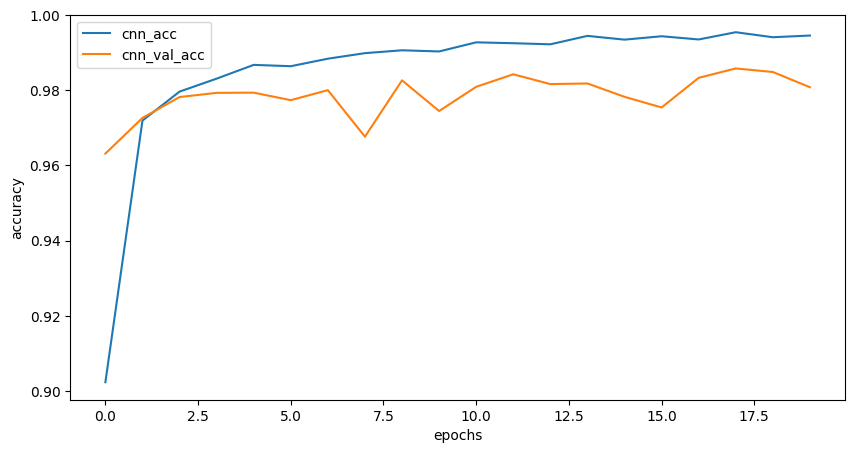

In [14]:
plt.figure(figsize=(10,5))
plt.plot(cnn_his.history["accuracy"], label="cnn_acc")
plt.plot(cnn_his.history["val_accuracy"], label="cnn_val_acc")
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.legend()
plt.show()

In [17]:
%cd /content/drive/MyDrive/00 딥러닝

/content/drive/MyDrive/00 딥러닝


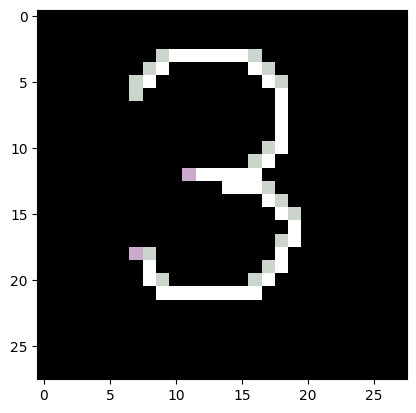

In [18]:
import PIL.Image as pimg # 사진 파일 다루는 라이브러리
img = pimg.open("./data/손글씨3.gif")
plt.imshow(img)
plt.show()

In [20]:
# 1차원으로 펴주는 Flatten이 받을 수 있도록 형변환 수행
# (28, 28) -> (n, 28, 28)
img.size
num = np.array(img) # 이미지 안에 있는 픽셀 값을 가지고 배열 생성
# 차원 수정 -> 문제 데이터와 동일한 형태로
num = num.reshape(1, 28, 28)
cnn_model.predict(num)[0].argmax() # 두 겹으로 싸여 있으니까 안쪽으로 한 번 들어가준다
# 0~9까지 클래스에 속할 확률
# argmax() : 배열 중에 값이 가장 큰 index를 돌려줌 -> 예측한 답 클래스

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step


np.int64(3)

In [21]:
cnn_model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9811 - loss: 0.0866


[0.0865800678730011, 0.9811000227928162]